In [20]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [21]:
class AgentState(TypedDict):
    query_type: str  # "general" or "backend"
    document_type: str  # "aadhaar", "pan", or "passport"
    kyc_status: str  # "pending", "processing", "success", "failed"
    processing_result: str  # "success" or "fail"
    face_recognition_result: str  # "success" or "fail"
    video_kyc_result: str  # "success" or "fail"

In [22]:
# Node functions
def query_testing_general_backend(state: AgentState) -> AgentState:
    """Query Testing (General/Backend)"""
    print("This is Query Testing (General/Backend)")
    return state

def general_query_agent(state: AgentState) -> AgentState:
    """General Query Agent"""
    print("This is General Query Agent")
    return state

def start_kyc(state: AgentState) -> AgentState:
    """Start KYC"""
    print("This is Start KYC")
    return state

def document_selection(state: AgentState) -> AgentState:
    """Document Selection"""
    print("This is Document Selection")
    return state

def aadhaar_agent(state: AgentState) -> AgentState:
    """Aadhaar Agent"""
    print("This is Aadhaar Agent")
    return state

def pan_agent(state: AgentState) -> AgentState:
    """Pan Agent"""
    print("This is Pan Agent")
    return state

def passport_agent(state: AgentState) -> AgentState:
    """Passport Agent"""
    print("This is Passport Agent")
    return state

def document_upload_image_format(state: AgentState) -> AgentState:
    """Document Upload (Image Format)"""
    print("This is Document Upload (Image Format)")
    return state

def document_processing_text_extraction(state: AgentState) -> AgentState:
    """Document Processing/Text Extraction"""
    print("This is Document Processing/Text Extraction")
    return state

def face_recognition_liveliness_check(state: AgentState) -> AgentState:
    """Face Recognition/Liveliness Check"""
    print("This is Face Recognition/Liveliness Check")
    return state

def video_kyc(state: AgentState) -> AgentState:
    """Video KYC"""
    print("This is Video KYC")
    return state

def complete(state: AgentState) -> AgentState:
    """Complete"""
    print("This is Complete")
    return state

def failed(state: AgentState) -> AgentState:
    """Failed"""
    print("This is Failed")
    return state

In [23]:
# Routing functions
def route_query_type(state: AgentState) -> str:
    """Route based on query type"""
    if state["query_type"] == "general":
        return "general_query"
    else:
        return "backend_query"

def route_document_type(state: AgentState) -> str:
    """Route based on document type"""
    if state["document_type"] == "aadhaar":
        return "aadhaar_path"
    elif state["document_type"] == "pan":
        return "pan_path"
    else:
        return "passport_path"

def route_processing_result(state: AgentState) -> str:
    """Route based on processing result"""
    if state["processing_result"] == "success":
        return "processing_success"
    else:
        return "processing_fail"

def route_face_recognition_result(state: AgentState) -> str:
    """Route based on face recognition result"""
    if state["face_recognition_result"] == "success":
        return "face_success"
    else:
        return "face_fail"

def route_video_kyc_result(state: AgentState) -> str:
    """Route based on video KYC result"""
    if state["video_kyc_result"] == "success":
        return "video_success"
    else:
        return "video_fail"

In [24]:
# Create the graph
graph = StateGraph(AgentState)

# Add nodes
graph.add_node("query_testing", query_testing_general_backend)
graph.add_node("general_query_agent", general_query_agent)
graph.add_node("start_kyc", start_kyc)
graph.add_node("document_selection", document_selection)
graph.add_node("aadhaar_agent", aadhaar_agent)
graph.add_node("pan_agent", pan_agent)
graph.add_node("passport_agent", passport_agent)
graph.add_node("document_upload", document_upload_image_format)
graph.add_node("document_processing", document_processing_text_extraction)
graph.add_node("face_recognition", face_recognition_liveliness_check)
graph.add_node("video_kyc", video_kyc)
graph.add_node("complete", complete)
graph.add_node("failed", failed)

In [25]:
# Add edges
graph.add_edge(START, "query_testing")

# Query type routing
graph.add_conditional_edges(
    "query_testing",
    route_query_type,
    {
        "general_query": "general_query_agent",
        "backend_query": "start_kyc"
    }
)

graph.add_edge("general_query_agent", END)
graph.add_edge("start_kyc", "document_selection")

# Document type routing
graph.add_conditional_edges(
    "document_selection",
    route_document_type,
    {
        "aadhaar_path": "aadhaar_agent",
        "pan_path": "pan_agent",
        "passport_path": "passport_agent"
    }
)

# All document agents go to document upload
graph.add_edge("aadhaar_agent", "document_upload")
graph.add_edge("pan_agent", "document_upload")
graph.add_edge("passport_agent", "document_upload")

# Document processing flow
graph.add_edge("document_upload", "document_processing")

graph.add_conditional_edges(
    "document_processing",
    route_processing_result,
    {
        "processing_success": "face_recognition",
        "processing_fail": "failed"
    }
)

# Face recognition flow
graph.add_conditional_edges(
    "face_recognition",
    route_face_recognition_result,
    {
        "face_success": "video_kyc",
        "face_fail": "failed"
    }
)

# Video KYC flow
graph.add_conditional_edges(
    "video_kyc",
    route_video_kyc_result,
    {
        "video_success": "complete",
        "video_fail": "failed"
    }
)

# End states
graph.add_edge("complete", END)
graph.add_edge("failed", END)

In [26]:
# Compile the graph
app = graph.compile()

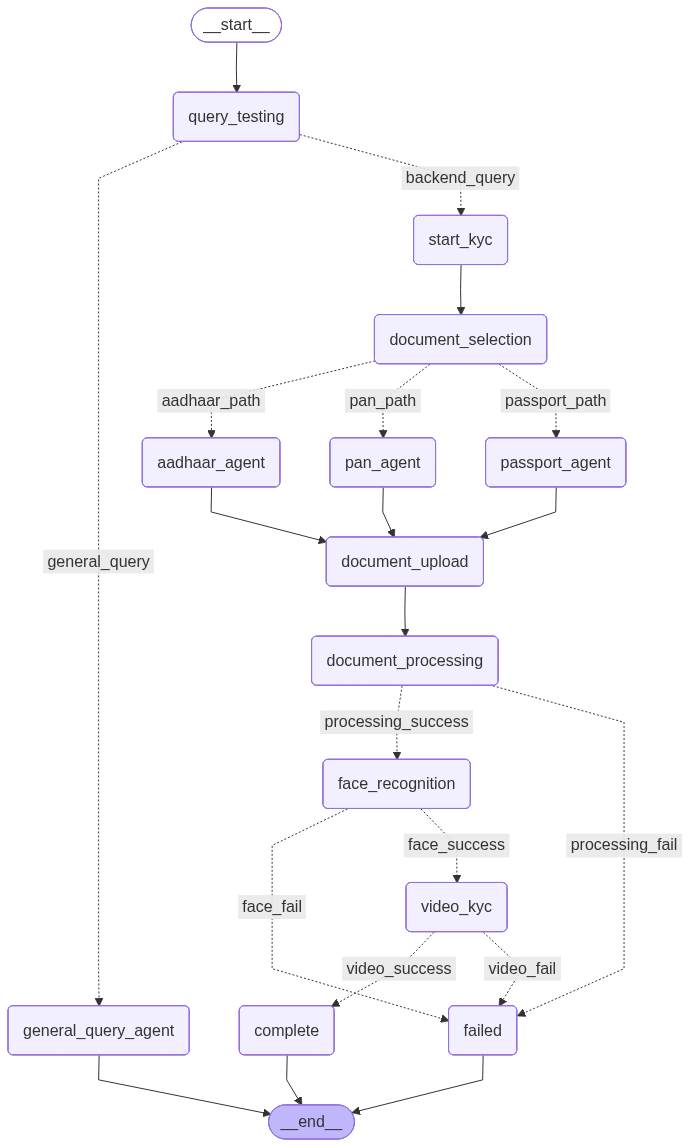

In [27]:
# Display the graph
display(Image(app.get_graph().draw_mermaid_png()))

In [28]:
# Test cases
print("=== Test Case 1: General Query ===")
initial_state_1 = AgentState(
    query_type="general",
    document_type="",
    kyc_status="pending",
    processing_result="",
    face_recognition_result="",
    video_kyc_result=""
)
result1 = app.invoke(initial_state_1)
print(f"Result: {result1}")

print("\n=== Test Case 2: Successful KYC with Aadhaar ===")
initial_state_2 = AgentState(
    query_type="backend",
    document_type="aadhaar",
    kyc_status="pending",
    processing_result="success",
    face_recognition_result="success",
    video_kyc_result="success"
)
result2 = app.invoke(initial_state_2)
print(f"Result: {result2}")

print("\n=== Test Case 3: Failed KYC - Ends Immediately ===")
initial_state_3 = AgentState(
    query_type="backend",
    document_type="pan",
    kyc_status="pending",
    processing_result="fail",
    face_recognition_result="success",
    video_kyc_result="success"
)
result3 = app.invoke(initial_state_3)
print(f"Final Result: {result3}")

print("\n=== Test Case 4: Multiple Failure Points ===")
initial_state_4 = AgentState(
    query_type="backend",
    document_type="passport",
    kyc_status="pending",
    processing_result="fail",
    face_recognition_result="fail",
    video_kyc_result="fail"
)
result4 = app.invoke(initial_state_4)
print(f"Final Result: {result4}")

=== Test Case 1: General Query ===
This is Query Testing (General/Backend)
This is General Query Agent
Result: {'query_type': 'general', 'document_type': '', 'kyc_status': 'pending', 'processing_result': '', 'face_recognition_result': '', 'video_kyc_result': ''}

=== Test Case 2: Successful KYC with Aadhaar ===
This is Query Testing (General/Backend)
This is Start KYC
This is Document Selection
This is Aadhaar Agent
This is Document Upload (Image Format)
This is Document Processing/Text Extraction
This is Face Recognition/Liveliness Check
This is Video KYC
This is Complete
Result: {'query_type': 'backend', 'document_type': 'aadhaar', 'kyc_status': 'pending', 'processing_result': 'success', 'face_recognition_result': 'success', 'video_kyc_result': 'success'}

=== Test Case 3: Failed KYC - Ends Immediately ===
This is Query Testing (General/Backend)
This is Start KYC
This is Document Selection
This is Pan Agent
This is Document Upload (Image Format)
This is Document Processing/Text Extra